# 02 — Telco baselines

**Objective:** Evaluate three deliberately simple Session 1 baselines—predict no churn, contact everyone, and apply a transparent business rule—before deciding whether a fitted model is necessary.

## Load the target and rule inputs

These baselines need only the churn label plus `Contract` and `tenure` for the business rule. No model is fitted in this notebook.

In [1]:
# Use Path so the repository-relative data location works across operating systems.
from pathlib import Path

# Import Matplotlib to title and render the confusion-matrix figures.
import matplotlib.pyplot as plt
# Import NumPy to create constant prediction arrays for the first two baselines.
import numpy as np
# Import pandas to load the CSV and organize metric and cost tables.
import pandas as pd
# Import only the classification tools needed for the three baseline comparisons.
from sklearn.metrics import (
    ConfusionMatrixDisplay,  # Turn each 2x2 count table into a labeled figure.
    accuracy_score,  # Measure the share of all predictions that are correct.
    confusion_matrix,  # Count TN, FP, FN, and TP from actual and predicted labels.
    precision_score,  # Measure how many contacted customers actually churned.
    recall_score,  # Measure how many actual churners the baseline identified.
)
# Import the splitter used to create one explicit, reproducible holdout.
from sklearn.model_selection import train_test_split

# Point from the notebooks folder to the course CSV stored in the repository.
data_path = Path("../data/telco.csv")
# Load one row per customer into a DataFrame.
df = pd.read_csv(data_path)

# Keep only the two columns required by the transparent business rule.
X = df[["Contract", "tenure"]]
# Encode Yes as 1 and No as 0 so scikit-learn can calculate binary metrics.
y = df["Churn"].eq("Yes").astype(int)

## Create the holdout

Session 1 presents prepared results for a 2,113-customer holdout, but its source material does not define a reproducible split or random seed. We therefore use the explicit assumption requested for this companion: a stratified 30% holdout with `random_state=42`. We do not search for a seed that reproduces the prepared confusion matrices.

Stratification keeps the churn proportion close to that of the full dataset. The training rows are created for a valid holdout boundary, although these three baselines do not learn from them.

In [2]:
# Separate aligned feature rows and labels before evaluating any baseline.
X_train, X_test, y_train, y_test = train_test_split(
    X,  # Split the rule inputs by customer row.
    y,  # Apply the same row split to the churn labels.
    test_size=0.30,  # Reserve 30%, which produces the 2,113-customer holdout.
    stratify=y,  # Preserve approximately the same churn proportion in both parts.
    random_state=42  # Make the random partition reproducible.
)

# Confirm the number of customers evaluated in the holdout.
print(f"Holdout customers: {len(y_test):,}")
# Show the actual class counts that every baseline will be evaluated against.
print(y_test.value_counts().rename(index={0: "No churn", 1: "Churn"}))

Holdout customers: 2,113
Churn
No churn    1552
Churn        561
Name: count, dtype: int64


In every confusion matrix, rows are actual outcomes and columns are predictions:

- **TN:** correctly leave a non-churner uncontacted.
- **FP:** contact a customer who would not churn.
- **FN:** miss a customer who does churn.
- **TP:** correctly identify and contact a churner.

## Baseline 1 — Do nothing

Predict no churn for every holdout customer. This produces no false alarms, but it cannot identify a single churner.

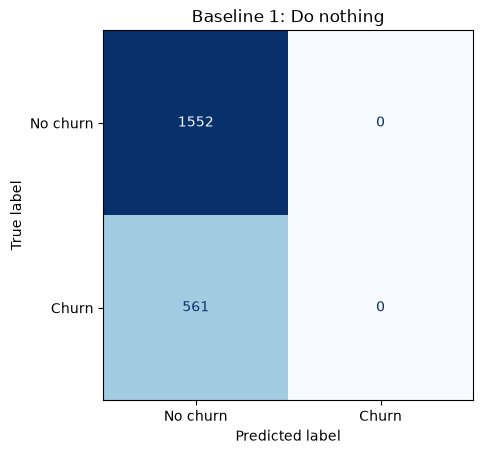

In [3]:
# Predict class 0 for every holdout customer to represent taking no action.
y_pred_do_nothing = np.zeros(len(y_test), dtype=int)
# Compare the actual labels with those constant predictions in a fixed 0/1 order.
cm_do_nothing = confusion_matrix(y_test, y_pred_do_nothing, labels=[0, 1])

# Build a labeled display so rows and columns are not confused.
ConfusionMatrixDisplay(
    confusion_matrix=cm_do_nothing,  # Supply the counts calculated from predictions.
    display_labels=["No churn", "Churn"]  # Translate 0/1 into business labels.
).plot(cmap="Blues", colorbar=False)
# Identify which baseline produced this matrix.
plt.title("Baseline 1: Do nothing")
# Render the completed matrix in this output cell.
plt.show()

In [4]:
# Store the three class metrics together so they can be compared later.
metrics_do_nothing = pd.Series({
    "Accuracy": accuracy_score(y_test, y_pred_do_nothing),  # Overall correctness.
    "Precision": precision_score(
        y_test,
        y_pred_do_nothing,
        zero_division=0  # Define precision as zero because no positive is predicted.
    ),
    "Recall": recall_score(y_test, y_pred_do_nothing),  # Share of churners found.
})
# Display the metrics for this baseline immediately after its confusion matrix.
metrics_do_nothing

Accuracy     0.734501
Precision    0.000000
Recall       0.000000
dtype: float64

The accuracy looks high because most customers do not churn. Precision and recall are both zero: the baseline never predicts churn.

## Baseline 2 — Contact everyone

Predict churn for every holdout customer. This finds every churner, but also contacts every non-churner.

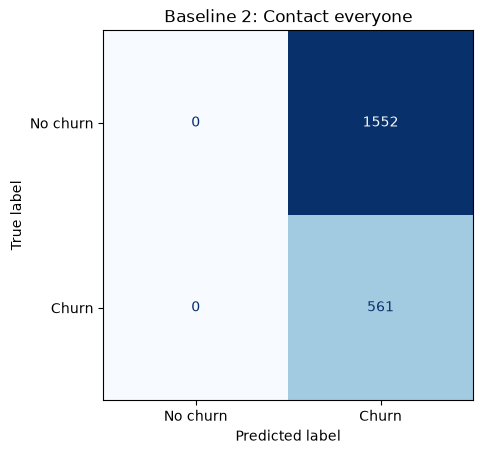

In [5]:
# Predict class 1 for every holdout customer to represent contacting everyone.
y_pred_contact_everyone = np.ones(len(y_test), dtype=int)
# Count the resulting TN, FP, FN, and TP in the same fixed order as before.
cm_contact_everyone = confusion_matrix(
    y_test,  # Use the observed churn outcomes as rows.
    y_pred_contact_everyone,  # Use the all-one predictions as columns.
    labels=[0, 1]  # Keep No churn before Churn in both axes.
)

# Build a labeled display so the false-positive volume is visible.
ConfusionMatrixDisplay(
    confusion_matrix=cm_contact_everyone,  # Supply the counts calculated above.
    display_labels=["No churn", "Churn"]  # Translate 0/1 into business labels.
).plot(cmap="Blues", colorbar=False)
# Identify which baseline produced this matrix.
plt.title("Baseline 2: Contact everyone")
# Render the completed matrix in this output cell.
plt.show()

In [6]:
# Calculate the same metrics so the baselines remain directly comparable.
metrics_contact_everyone = pd.Series({
    "Accuracy": accuracy_score(y_test, y_pred_contact_everyone),  # Overall correctness.
    "Precision": precision_score(y_test, y_pred_contact_everyone),  # Contact relevance.
    "Recall": recall_score(y_test, y_pred_contact_everyone),  # Share of churners found.
})
# Display the metrics for this baseline immediately after its confusion matrix.
metrics_contact_everyone

Accuracy     0.265499
Precision    0.265499
Recall       1.000000
dtype: float64

Recall is one because no churner is missed. Precision is much lower because every non-churner is a false positive.

## Baseline 3 — Business rule

Apply the exact Session 1 rule: predict churn when a customer has a month-to-month contract **and** tenure below 12 months. This is a transparent rule, not a fitted machine-learning model.

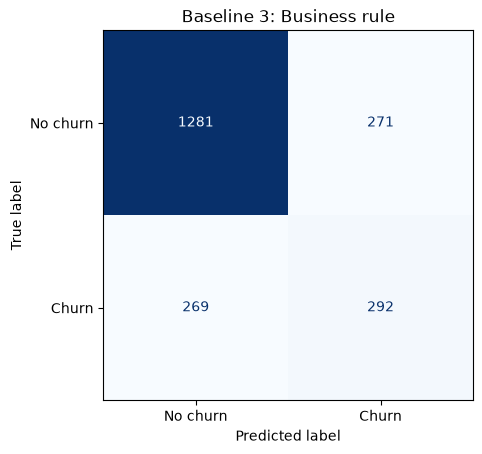

In [7]:
# Apply both Session 1 conditions to every customer in the holdout.
y_pred_business_rule = (
    X_test["Contract"].eq("Month-to-month")  # Require a flexible monthly contract.
    & X_test["tenure"].lt(12)  # Also require fewer than 12 months of tenure.
).astype(int)

# Count the rule's TN, FP, FN, and TP against the observed outcomes.
cm_business_rule = confusion_matrix(y_test, y_pred_business_rule, labels=[0, 1])

# Build a labeled display to make the rule's error trade-off visible.
ConfusionMatrixDisplay(
    confusion_matrix=cm_business_rule,  # Supply counts generated from the rule.
    display_labels=["No churn", "Churn"]  # Translate 0/1 into business labels.
).plot(cmap="Blues", colorbar=False)
# Identify which baseline produced this matrix.
plt.title("Baseline 3: Business rule")
# Render the completed matrix in this output cell.
plt.show()

In [8]:
# Calculate the same metrics so the rule can be compared with both extremes.
metrics_business_rule = pd.Series({
    "Accuracy": accuracy_score(y_test, y_pred_business_rule),  # Overall correctness.
    "Precision": precision_score(y_test, y_pred_business_rule),  # Contact relevance.
    "Recall": recall_score(y_test, y_pred_business_rule),  # Share of churners found.
})
# Display the metrics for this baseline immediately after its confusion matrix.
metrics_business_rule

Accuracy     0.744439
Precision    0.518650
Recall       0.520499
dtype: float64

The rule trades some false alarms for the ability to identify part of the churn population. With this documented assumption, its counts match the prepared Session 1 matrix. The source still does not state the split procedure, so we present the 30% stratified split with seed 42 as an explicit assumption rather than as recovered metadata.

## Compare the metrics

In [9]:
# Combine the three Series so each baseline becomes one comparison row.
metrics = pd.DataFrame({
    "Do nothing": metrics_do_nothing,  # Add the all-zero predictions.
    "Contact everyone": metrics_contact_everyone,  # Add the all-one predictions.
    "Business rule": metrics_business_rule,  # Add the transparent rule predictions.
}).T

# Round only the display, keeping the underlying metric values unchanged.
metrics.round(3)

,Accuracy,Precision,Recall
Do nothing,0.735,0.000,0.00
Contact everyone,0.265,0.265,1.00
Business rule,0.744,0.519,0.52


## Apply the business costs

Session 1 uses the illustrative calculation below:

`total cost = contacts × contact cost + false negatives × missed-churn cost`

Here, `contacts = TP + FP`: everyone predicted to churn is contacted. The calculation deliberately assumes every contacted churner is retained. That is a teaching assumption, not a measured causal effect.

In [10]:
# Unpack the first matrix in the documented TN, FP, FN, TP order.
tn_do_nothing, fp_do_nothing, fn_do_nothing, tp_do_nothing = cm_do_nothing.ravel()
# Unpack the second matrix using the same orientation.
tn_contact_all, fp_contact_all, fn_contact_all, tp_contact_all = cm_contact_everyone.ravel()
# Unpack the business-rule matrix using the same orientation.
tn_rule, fp_rule, fn_rule, tp_rule = cm_business_rule.ravel()

# Keep only the counts required by the Session 1 cost formula.
baseline_counts = pd.DataFrame({
    "Contacts": [
        tp_do_nothing + fp_do_nothing,  # Every positive prediction is contacted.
        tp_contact_all + fp_contact_all,  # Every positive prediction is contacted.
        tp_rule + fp_rule,  # Every positive prediction is contacted.
    ],
    "False negatives": [fn_do_nothing, fn_contact_all, fn_rule],  # Missed churners.
}, index=["Do nothing", "Contact everyone", "Business rule"])

# Display the two quantities before attaching monetary assumptions.
baseline_counts

,Contacts,False negatives
Do nothing,0,561
Contact everyone,2113,0
Business rule,563,269


In [11]:
# Create one result row per baseline and one column per cost scenario.
costs = pd.DataFrame(index=baseline_counts.index)
# Price contacts highly and missed churners relatively lightly.
costs["Protect the budget"] = (
    baseline_counts["Contacts"] * 200  # Apply the €200 cost to each contact.
    + baseline_counts["False negatives"] * 100  # Apply €100 to each missed churner.
)
# Give contacts and missed churners more balanced business consequences.
costs["Balance intervention and loss"] = (
    baseline_counts["Contacts"] * 100  # Apply the €100 cost to each contact.
    + baseline_counts["False negatives"] * 200  # Apply €200 to each missed churner.
)
# Make missing a churner much more expensive than making a contact.
costs["Protect retained value"] = (
    baseline_counts["Contacts"] * 30  # Apply the €30 cost to each contact.
    + baseline_counts["False negatives"] * 300  # Apply €300 to each missed churner.
)

# Format totals as euros and highlight the cheapest baseline within each scenario.
costs.style.format("€{:,.0f}").highlight_min(axis=0, color="#d9ead3")

,Protect the budget,Balance intervention and loss,Protect retained value
Do nothing,"€56,100","€112,200","€168,300"
Contact everyone,"€422,600","€211,300","€63,390"
Business rule,"€139,500","€110,100","€97,590"


The lowest-cost baseline changes with the relative cost of intervention and missed churn. A high contact cost favors restraint; a high missed-churn cost can justify contacting many more customers.

## Is a more sophisticated model actually necessary?

A baseline is not merely a leaderboard score to beat. It establishes what can already be achieved with almost no modelling effort and makes the relevant error trade-offs visible. A fitted model is useful only if it improves the decision under the costs and constraints that matter.